In [562]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [563]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [564]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [565]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [566]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [567]:
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 64  # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1  # added b1 back, even though batchnorm makes it redundant
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# Batchorm parameters
bngain = torch.randn((1, n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1, n_hidden)) * 0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

4137


In [568]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [569]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3285, grad_fn=<NegBackward0>)

In [570]:
counts_sum_inv.shape

torch.Size([32, 1])

In [571]:
Xb[:5]

tensor([[ 1,  1,  4],
        [18, 14,  1],
        [11,  5,  9],
        [ 0,  0,  1],
        [12, 15, 14]])

In [572]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

# loss = -logprobs[range(n), Yb].mean()  takes the logprobs for each correct next character, for each of n=32
dlogprobs = torch.zeros_like(logprobs)  #.zeros((32, 27))
dlogprobs[range(n), Yb] = -1.0 / n  # where x.sum()/n is x.mean(). most of the numbers do not impact the loss, only those of the correct index.

# logprobs = probs.log()
dprobs = (1.0 / probs) * dlogprobs  # intuitively, high prob for correct -> low grad; low prob for correct -> high grad
# print(dprobs.shape, probs.shape, dlogprobs.shape)  # all same dim

# probs = counts * counts_sum_inv  (note: (32, 27) * (32, 1))
dcounts = counts_sum_inv * dprobs  # broadcasts correctly
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)  # since counts_sum_inv was broadcasted/replicated from 1->27 columns, we sum each row (sum columns); we sum its uses
# print(dcounts_sum_inv.shape)

# counts_sum_inv = counts_sum**-1
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv 

# counts_sum = counts.sum(1, keepdims=True)
dcounts += torch.ones_like(counts) * dcounts_sum  # summed each row when forward, now broadcasts back (also, added since 2nd branch)
# print(counts.shape, dcounts_sum.shape)  # 

# counts = norm_logits.exp()
dnorm_logits = counts * dcounts

# norm_logits = logits - logit_maxes # subtract max for numerical stability
dlogits = dnorm_logits.clone()  #torch.ones_like(logits) * dnorm_logits
dlogit_maxes = -dnorm_logits.sum(1, keepdim=True)  # broadcasted during forward, now summed as branches when backwards
# print(norm_logits.shape, logits.shape, logit_maxes.shape)
# print(dnorm_logits.shape, dlogits.shape, dlogit_maxes.shape)

# logit_maxes = logits.max(1, keepdim=True).values
# NOTE: This branch is only done for numerical stability, and SHOULD HAVE GRADIENT OF ZERO. However, floating point makes it weird.
# We got the maxes in each row furing the forward pass, but then want to scatter the loss back to from where the logits came.
# dlogits_max_mask = torch.zeros_like(logits)
# dlogits_max_mask[torch.arange(n), logits.argmax(1)] = 1.0  # mask can be made with F.one_hot
# dlogits += dlogits_max_mask * dlogit_maxes
dlogits += F.one_hot(logits.argmax(1), num_classes=logits.shape[1]) * dlogit_maxes  # logits.argmax(1) == logits.max(1).indices
# plt.imshow(F.one_hot(logits.argmax(1), num_classes=logits.shape[1]))

# ------------------------

# logits = h @ W2 + b2 # output layer  # if you don't remember the orders, just make sure the dimensions work out.
dh = dlogits @ W2.t()
dW2 = h.t() @ dlogits
db2 = dlogits.sum(0)  # corresonponding to each neuron, sums branches across rows (diff examples)

# h = torch.tanh(hpreact) # hidden layer
dhpreact = (1 - h**2) * dh

# hpreact = bngain * bnraw + bnbias
# print(dhpreact.shape, bngain.shape, bnraw.shape, bnbias.shape)
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)  # note: gain across each neuron (oputput feature), not input features.
dbnraw = bngain * dhpreact  # broadcasts correctly
dbnbias = dhpreact.sum(0, keepdim=True)
# print(dbngain.shape, dbnraw.shape, dbnbias.shape)

# bnraw = bndiff * bnvar_inv
# print(bnraw.shape, bndiff.shape, bnvar_inv.shape)  # (32, 64), (32, 64), (1, 64)
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)  # variance sums by each output feature/neuron -> columns are neurons
dbndiff = bnvar_inv * dbnraw  # broadcasts (1,64)*(32,64), variance is by feature (over 32 examples)

# bnvar_inv = (bnvar + 1e-5)**-0.5
# dbnvar = -0.5 * bnvar_inv**3 * dbnvar_inv  # efficient but doesn't seem to be exact...
dbnvar = -0.5 * (bnvar + 1e-5)**-1.5 * dbnvar_inv

# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
dbndiff2 = torch.ones_like(bndiff2)/(n-1) * dbnvar

# bndiff2 = bndiff**2
dbndiff += (2.0*bndiff) * dbndiff2

# bndiff = hprebn - bnmeani
# print(bndiff.shape, hprebn.shape, bnmeani.shape)
dhprebn = dbndiff.clone()
dbnmeani = -dbndiff.sum(0, keepdim=True)
# print(dbndiff.shape, dhprebn.shape, dbnmeani.shape)

# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
dhprebn += torch.ones_like(hprebn)/n * dbnmeani

# hprebn = embcat @ W1 + b1 # hidden layer pre-activation
dembcat = dhprebn @ W1.t()
dW1 = embcat.t() @ dhprebn
db1 = dhprebn.sum(0)  # corresonponding to each neuron, sums branches across rows (diff examples)

# embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# print(emb.shape, embcat.shape)
demb = dembcat.view(emb.shape)

# emb = C[Xb] # embed the characters into vectors (32, 3) -> (32, 3, 10)
dC = torch.zeros_like(C)  # (27, 10) | so we can add the corresponding gradient of a char to embedding row each time it appears
for i in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[i][j]
        dC[ix] += demb[i, j]  # add corresponding gradient to the row in lookup
# print(C)

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [573]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.328510046005249 diff: 0.0


In [574]:
# backward pass

# -----------------
dlogits = F.softmax(logits, 1)  #probs.clone()
dlogits -= F.one_hot(Yb, num_classes=logits.shape[1])
dlogits /= n  # scale down since loss is mean over batch of 32 (i.e. d(average_loss)/d(contributed_loss) )
# -----------------

# print(dlogits[:5])
# print(logits.grad[:5])
# print(logits.grad[1].sum(0))

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9
dlogits.shape, logits.shape, F.one_hot(Yb, num_classes=logits.shape[1]).shape

logits          | exact: False | approximate: True  | maxdiff: 6.28642737865448e-09


(torch.Size([32, 27]), torch.Size([32, 27]), torch.Size([32, 27]))

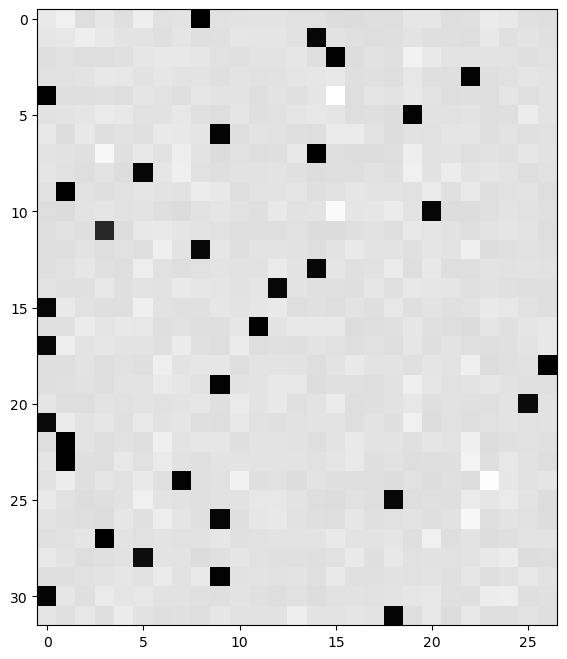

In [575]:
# If all probs ideal, there would be no gradient. It's like a pully system:
# we pull down on the probability of the incorrect characters (positive gradient)
# and we pull up on the probability of the correct character (negative gradient)
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap='gray')

In [576]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [577]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - (dhpreact*bnraw).sum(0)*n/(n-1)*bnraw)
# -----------------
# Note: we have to be careful that it is for all x_i at once, and broadcasts the mean and variance terms correctly across 32 examples.
print(dhprebn.shape, bngain.shape, bnvar_inv.shape, dhpreact.shape, dhpreact.sum(0).shape, bnraw.shape, dbnraw.sum(0).shape, sep="\n")

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

torch.Size([32, 64])
torch.Size([1, 64])
torch.Size([1, 64])
torch.Size([32, 64])
torch.Size([64])
torch.Size([32, 64])
torch.Size([64])
hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [578]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

    # kick off optimization
    for i in range(max_steps):

        # minibatch construct
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

        # forward pass
        emb = C[Xb] # embed the characters into vectors
        embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
        # Linear layer
        hprebn = embcat @ W1 + b1 # hidden layer pre-activation
        # BatchNorm layer
        # -------------------------------------------------------------
        bnmean = hprebn.mean(0, keepdim=True)
        bnvar = hprebn.var(0, keepdim=True, unbiased=True)
        bnvar_inv = (bnvar + 1e-5)**-0.5
        bnraw = (hprebn - bnmean) * bnvar_inv
        hpreact = bngain * bnraw + bnbias
        # -------------------------------------------------------------
        # Non-linearity
        h = torch.tanh(hpreact) # hidden layer
        logits = h @ W2 + b2 # output layer
        loss = F.cross_entropy(logits, Yb) # loss function

        # backward pass
        for p in parameters:
            p.grad = None
        # loss.backward() # use this for correctness comparisons, to be deleted

        # manual backprop! #swole_doge_meme
        # -----------------
        # softmax + cross entropy
        dlogits = F.softmax(logits, 1)  #probs.clone()
        dlogits -= F.one_hot(Yb, num_classes=logits.shape[1])
        dlogits /= n  # scale down since loss is mean over batch of 32 (i.e. d(average_loss)/d(contributed_loss) )
        # layer 2
        dh = dlogits @ W2.t()
        dW2 = h.t() @ dlogits
        db2 = dlogits.sum(0)
        dhpreact = (1 - h**2) * dh  # tanh
        # batchnorm
        dbngain = (bnraw * dhpreact).sum(0, keepdim=True)  # gain across each neuron (oputput feature)
        dbnbias = dhpreact.sum(0, keepdim=True)
        dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - (dhpreact*bnraw).sum(0)*n/(n-1)*bnraw)
        # layer 1
        dembcat = dhprebn @ W1.t()
        dW1 = embcat.t() @ dhprebn
        db1 = dhprebn.sum(0)
        # embedding
        demb = dembcat.view(emb.shape)
        dC = torch.zeros_like(C)
        for k in range(Xb.shape[0]):
            for j in range(Xb.shape[1]):
                ix = Xb[k][j]
                dC[ix] += demb[k, j]
        grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
        # -----------------

        # update
        lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
        for p, grad in zip(parameters, grads):
            # p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
            p.data += -lr * grad # new way of swole doge TODO: enable

        # track stats
        if i % 10000 == 0: # print every once in a while
            print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        lossi.append(loss.log10().item())

        # if i >= 100: # TODO: delete early breaking when you're ready to train the full net
        #     break

12297
      0/ 200000: 3.7915
  10000/ 200000: 2.1506
  20000/ 200000: 2.3290
  30000/ 200000: 2.4170
  40000/ 200000: 2.0033
  50000/ 200000: 2.3652
  60000/ 200000: 2.4195
  70000/ 200000: 2.0614
  80000/ 200000: 2.3232
  90000/ 200000: 2.0949
 100000/ 200000: 1.9916
 110000/ 200000: 2.3190
 120000/ 200000: 2.0202
 130000/ 200000: 2.4757
 140000/ 200000: 2.3262
 150000/ 200000: 2.2140
 160000/ 200000: 1.9689
 170000/ 200000: 1.8380
 180000/ 200000: 1.9893
 190000/ 200000: 1.9819


In [580]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [581]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)


In [582]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.069059133529663
val 2.1074748039245605


In [ ]:
# Karpathy achieved:
# train 2.0718822479248047
# val 2.1162495613098145

### My Results:
# With loss.backward():
# train 2.0700111389160156
# val 2.1081836223602295

# With manual backprop
# train 2.069059133529663
# val 2.1074748039245605

### Pretty good!

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmahzamille.
khi.
mri.
reetlanna.
sane.
mahnen.
den.
art.
kaeli.
nellara.
chaiivon.
leigh.
ham.
join.
quinn.
shoilea.
jadbi.
wavero.
dearisi.
jace.
